# MNIST Nearest-Neighbour Classifier

A **1-NN classifier** using Euclidean distance on the full MNIST training set (60,000 images).  
The training set is processed in chunks of 1,000 to keep memory usage manageable.

In [111]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

## 1. Load and Inspect the MNIST Data
 
- `trainv` / `trainlab` — 60,000 training images and their labels  
- `testv` / `testlab` — 10,000 held-out test images and their labels  

Each image is a flattened 28×28 = **784-dimensional** vector.

In [112]:
data = sio.loadmat('data_all.mat')

train_images = data['trainv'].astype(np.float64) 
train_labels = data['trainlab'].flatten()        
test_images  = data['testv'].astype(np.float64)    
test_labels  = data['testlab'].flatten()            

## 2. Define the Nearest-Neighbour Classifier

For every test image the closest training image is found using the vectorised squared Euclidean distance:

$$\|x - y\|^2 = \|x\|^2 + \|y\|^2 - 2\, x^\top y$$

Processing the training set in **chunks of 1,000** keeps the distance matrix at a manageable `(N_test × 1000)` size rather than `(N_test × 60,000)`.

In [113]:
CHUNK_SIZE = 1000

def nn_predict(test_images, train_images, train_labels, chunk_size=CHUNK_SIZE):
    num_test_images = test_images.shape[0]
    num_train_images = train_images.shape[0]

    test_square = np.sum(test_images ** 2, axis=1)

    best_distance = np.full(num_test_images, np.inf)
    best_label = np.zeros(num_test_images, dtype=train_labels.dtype)

    num_chunks = int(np.ceil(num_train_images / chunk_size))
    for chunk_index in range(num_chunks):
        start = chunk_index * chunk_size
        end = min(start + chunk_size, num_train_images)

        chunk_images = train_images[start:end]
        chunk_labels = train_labels[start:end]
        train_square = np.sum(chunk_images ** 2, axis=1)

        squared_distances = (
            test_square[:, None] + train_square[None, :] - 2.0 * test_images @ chunk_images.T
        )
        np.clip(squared_distances, 0, None, out=squared_distances)

        chunk_best_index = np.argmin(squared_distances, axis=1)
        chunk_best_distance = squared_distances[np.arange(num_test_images), chunk_best_index]

        improved = chunk_best_distance < best_distance
        best_distance[improved] = chunk_best_distance[improved]
        best_label[improved] = chunk_labels[chunk_best_index[improved]]

    return best_label

## 3. Run Classification on the Test Set

Call `nn_predict()` with the full training set and all 10,000 test images. Progress is printed every 10 chunks (~every 10,000 training images scanned).

In [114]:
predictions = nn_predict(test_images, train_images, train_labels)

## 4. Evaluate Accuracy and Error Rate

Overall **accuracy** = fraction of test images classified correctly.  
**Error rate** = 1 − accuracy.

In [115]:
accuracy = np.mean(predictions == test_labels) * 100
num_errors = np.sum(predictions != test_labels)

print(f"Results")
print(f"-------")
print(f"Test samples : {len(test_labels)}")
print(f"Correct      : {len(test_labels) - num_errors}")
print(f"Errors       : {num_errors}")
print(f"Accuracy     : {accuracy:.2f}%")
print(f"Error rate   : {100 - accuracy:.2f}%")

Results
-------
Test samples : 10000
Correct      : 9691
Errors       : 309
Accuracy     : 96.91%
Error rate   : 3.09%


## 5. Confusion Matrix

The confusion matrix $C$ is a 10×10 table where $C_{i,j}$ = number of images with true label $i$ predicted as $j$.  
- **Diagonal** → correct classifications  
- **Off-diagonal** → misclassifications

Per-class error rate for digit $c$:

$$\text{error}_c = \frac{\text{row sum}_c - C_{c,c}}{\text{row sum}_c} \times 100\%$$

In [116]:
class_labels = np.arange(10)
num_classes = len(class_labels)

confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)
for true_label, predicted_label in zip(test_labels, predictions):
    confusion_matrix[int(true_label), int(predicted_label)] += 1

for class_label in class_labels:
    class_total = confusion_matrix[class_label].sum()
    class_error_rate = (class_total - confusion_matrix[class_label, class_label]) / class_total * 100

## 6. Visualise the Confusion Matrix as a Heatmap

Darker cells = more samples. White text is used when the cell is dark enough to make black text hard to read. The figure is also saved to `confusion_matrix.png`.

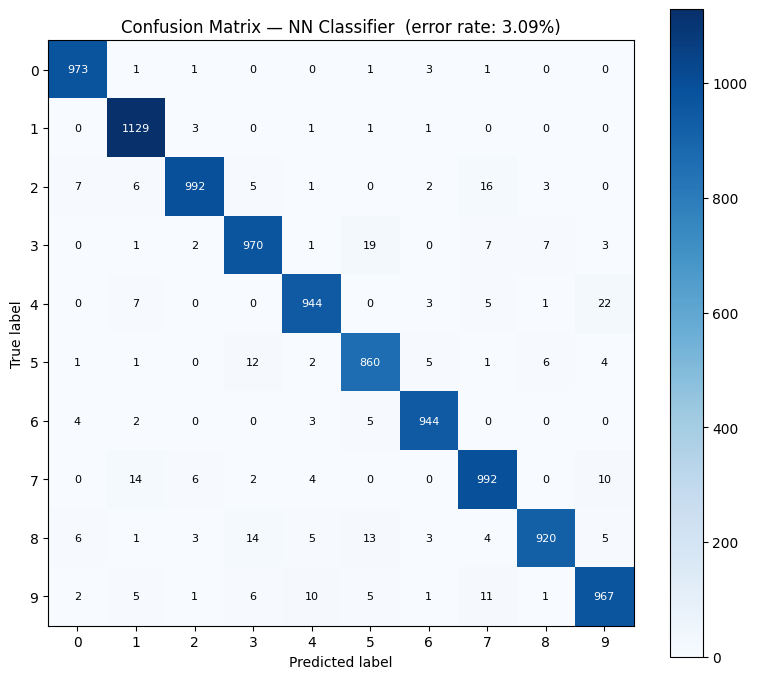

In [117]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(confusion_matrix, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(class_labels)
ax.set_yticks(class_labels)
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Confusion Matrix — NN Classifier  (error rate: {100 - accuracy:.2f}%)")

for row_index in class_labels:
    for column_index in class_labels:
        text_color = "white" if confusion_matrix[row_index, column_index] > confusion_matrix.max() / 2 else "black"
        ax.text(column_index, row_index, str(confusion_matrix[row_index, column_index]),
                ha="center", va="center", fontsize=8, color=text_color)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 7. Visualise Misclassified Digits (3x3)

This cell finds test images where prediction != true label and plots 9 examples in a 3x3 grid.

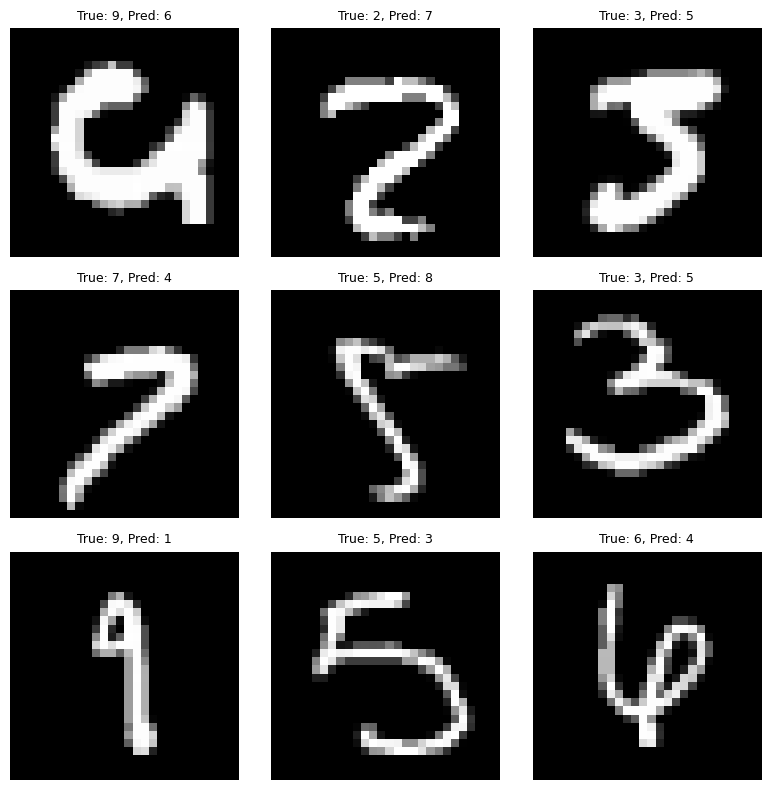

In [118]:
misclassified_indices = np.where(predictions != test_labels)[0]

selected_indices = misclassified_indices[100:109]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.flatten()

for plot_index, image_index in enumerate(selected_indices):
    image_matrix = test_images[image_index, :].reshape((28, 28))
    axes[plot_index].imshow(image_matrix, cmap='gray')
    axes[plot_index].set_title(
        f"True: {int(test_labels[image_index])}, Pred: {int(predictions[image_index])}",
        fontsize=9
    )
    axes[plot_index].axis('off')

for plot_index in range(len(selected_indices), 9):
    axes[plot_index].axis('off')

plt.tight_layout()
plt.show()

## 8. Visualise Correctly Classified Digits (3x3)

This cell finds test images where prediction == true label and plots 9 examples in a 3x3 grid.

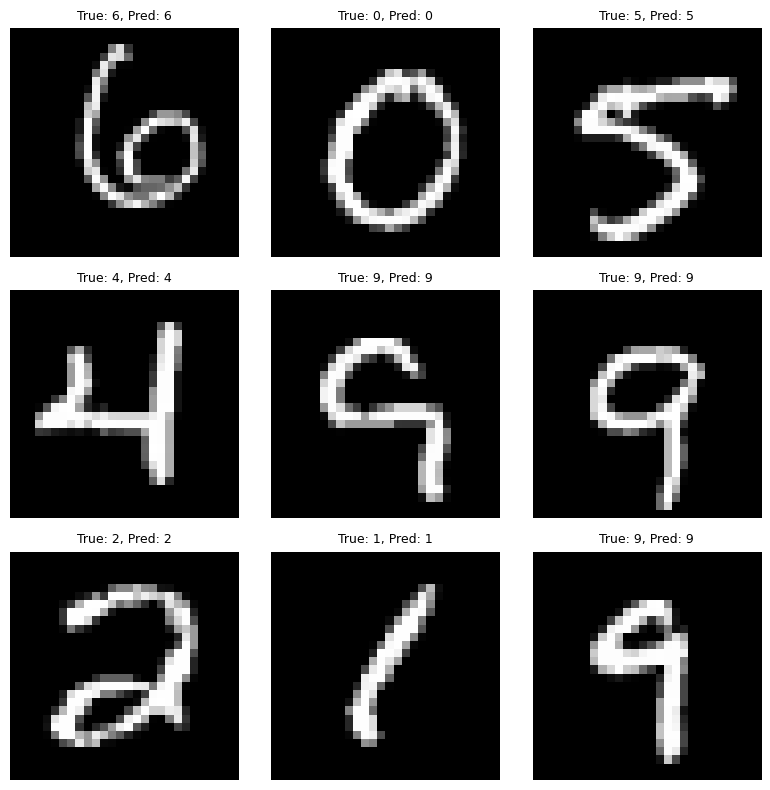

In [119]:
correct_indices = np.where(predictions == test_labels)[0]

selected_correct_indices = correct_indices[100:109]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.flatten()

for plot_index, image_index in enumerate(selected_correct_indices):
    image_matrix = test_images[image_index, :].reshape((28, 28))
    axes[plot_index].imshow(image_matrix, cmap='gray')
    axes[plot_index].set_title(
        f"True: {int(test_labels[image_index])}, Pred: {int(predictions[image_index])}",
        fontsize=9
    )
    axes[plot_index].axis('off')

for plot_index in range(len(selected_correct_indices), 9):
    axes[plot_index].axis('off')

plt.tight_layout()
plt.show()